# Middle-earth Time Generator

Converts sparse, human-edited mileage anchors into a **continuous daily Middle-earth timeline**
for each of the three Walk-to-Mordor journeys.

## Architecture

```
data/me-time-anchors.csv  (human-edited, source of truth)
          |
          v  movement model (this notebook)
          |
docs/static/data/me_time.csv  (generated output)
```

These files are **read-only** in this notebook:
- `docs/static/data/chronology.json` -- narrative events (not a mileage source)
- `docs/static/data/routes.json` -- visual geography
- `walking.csv` -- real-world "My Time" data

## Output schema
```
me_year, me_date, me_ordinal, journey_id, cumulative_miles
2941, 2941-04-27, 117, Hobbit, 0.0
2941, 1 Lithe, 181, Hobbit, 491.0
3018, 3018-09-23, 28341, Mordor, 0.0
3019, 3019-02-26, 28527, Mordor, 1367.0
3019, 3019-02-26, 28527, Return, 0.0
```

`me_date` is always a Shire Calendar string — never a Gregorian date.
`me_ordinal` is an absolute integer counting Shire Calendar days from T.A. 2941 Yule 2 (ordinal 0).

Multiple journeys may share the same `me_ordinal` (Mordor and Return overlap in T.A. 3019).

## Expected final mileages (Conqueror route totals — authoritative)
| Journey | Total |
|---------|-------|
| Hobbit  | 1100  |
| Mordor  | 1815  |
| Return  | 1482  |


## Middle-earth Calendar

Python's `datetime` module **cannot be used** for Shire Calendar dates because February has 30 days and special intercalary days exist.

### Within-year ordinal mapping (non-leap year)

```
Yule 2 (New Year equiv.)  ordinal 0
Months 1-6  (30 days ea.) ordinals 1-180
1 Lithe                   ordinal 181
Midyear's Day             ordinal 182
2 Lithe                   ordinal 183
Months 7-12 (30 days ea.) ordinals 184-363
Yule 1 (Last day)         ordinal 364
                          ---------
                          365 days total
```

**Leap years** (year % 4 == 0) insert Overlithe at ordinal 183, pushing 2 Lithe to 184,
months 7-12 to ordinals 185-364, Yule 1 to ordinal 365 (366 days total).

Month M, Day D ordinal formulas:
- Months 1-6:  `(M-1)*30 + D`
- Months 7-12 (non-leap): `(M-1)*30 + D + 3`
- Months 7-12 (leap):     `(M-1)*30 + D + 4`

In [1]:
from __future__ import annotations
import re, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Locate repo root (works from notebooks/ or repo root)
_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
assert (REPO_ROOT / "data").exists(), f"Cannot locate repo root from {_cwd}"

ANCHOR_PATH = REPO_ROOT / "data" / "me-time-anchors.csv"
CHRON_PATH  = REPO_ROOT / "docs" / "static" / "data" / "chronology.json"
OUTPUT_PATH = REPO_ROOT / "docs" / "static" / "data" / "me_time.csv"

# Authoritative Conqueror route totals
JOURNEY_TOTALS = {"Hobbit": 1100, "Mordor": 1815, "Return": 1482}

print(f"Repo root : {REPO_ROOT}")
print(f"Anchors   : {ANCHOR_PATH}  exists={ANCHOR_PATH.exists()}")
print(f"Chronology: {CHRON_PATH}  exists={CHRON_PATH.exists()}")

Repo root : c:\Users\johbr\Data-Analyst\Projects\Walk-to-Mordor
Anchors   : c:\Users\johbr\Data-Analyst\Projects\Walk-to-Mordor\data\me-time-anchors.csv  exists=True
Chronology: c:\Users\johbr\Data-Analyst\Projects\Walk-to-Mordor\docs\static\data\chronology.json  exists=True


In [2]:
# ── Shire Calendar ───────────────────────────────────────────────────────
_DATE_RE = re.compile(r"^(\d{4})-(\d{2})-(\d{2})$")

def _is_leap(year: int) -> bool:
    return year % 4 == 0

def _days_in_year(year: int) -> int:
    return 366 if _is_leap(year) else 365

def _yord_from_month_day(year: int, month: int, day: int) -> int:
    if not (1 <= month <= 12):
        raise ValueError(f"Month {month} out of range 1-12")
    if not (1 <= day <= 30):
        raise ValueError(f"Day {day} out of range 1-30 (all Shire months have 30 days)")
    extra = 4 if _is_leap(year) else 3
    return (month - 1) * 30 + day + (0 if month <= 6 else extra)

def _special_yord(name: str, year: int) -> int:
    key  = name.lower().strip()
    leap = _is_leap(year)
    if key in ("yule 2",):                              return 0
    if key in ("1 lithe", "lithe 1"):                   return 181
    if key in ("midyear's day", "midsummer's day"):     return 182
    if key == "overlithe":
        if not leap:
            raise ValueError(f"Overlithe only exists in leap years; {year} is not")
        return 183
    if key in ("2 lithe", "lithe 2"):                   return 184 if leap else 183
    if key in ("yule 1",):                              return 365 if leap else 364
    raise ValueError(f"Unknown special day: '{name}'")

def _yord_to_label(year: int, yord: int) -> str:
    leap  = _is_leap(year)
    extra = 4 if leap else 3
    yule1 = 365 if leap else 364
    l2    = 184 if leap else 183
    if yord == 0:              return "Yule 2"
    if yord == yule1:          return "Yule 1"
    if yord == 181:            return "1 Lithe"
    if yord == 182:            return "Midyear's Day"
    if leap and yord == 183:   return "Overlithe"
    if yord == l2:             return "2 Lithe"
    if yord <= 180:
        m = (yord - 1) // 30 + 1
        d = (yord - 1) % 30 + 1
    else:
        adj = yord - (180 + extra)
        if adj < 1 or adj > 180:
            raise ValueError(f"Unexpected year_ordinal {yord} for year {year}")
        m = (adj - 1) // 30 + 7
        d = (adj - 1) % 30 + 1
    return f"{year:04d}-{m:02d}-{d:02d}"

_abs_cache: dict[int, int] = {}
_BASE = 2941

def _abs_start(year: int) -> int:
    if year not in _abs_cache:
        acc = 0
        if year >= _BASE:
            for y in range(_BASE, year):
                acc += _days_in_year(y)
        else:
            for y in range(year, _BASE):
                acc -= _days_in_year(y)
        _abs_cache[year] = acc
    return _abs_cache[year]

def parse_me_date(label: str, year_hint: int | None = None) -> dict:
    """
    Parse a Shire Calendar date string.
    Returns dict(year, label, yord, abs_ord).
    Accepts "YYYY-MM-DD" (months 1-12, days 1-30) or special day names.
    Special days require year_hint.
    """
    label = label.strip()
    m = _DATE_RE.match(label)
    if m:
        year, month, day = int(m.group(1)), int(m.group(2)), int(m.group(3))
        yord = _yord_from_month_day(year, month, day)
    else:
        if year_hint is None:
            raise ValueError(f"Special day '{label}' requires year_hint")
        year = int(year_hint)
        yord = _special_yord(label, year)
    return {"year": year, "label": label, "yord": yord,
            "abs_ord": _abs_start(year) + yord}

def _next_yord(year: int, yord: int) -> tuple[int, int]:
    max_ord = 365 if _is_leap(year) else 364
    if yord < max_ord:
        return year, yord + 1
    return year + 1, 0      # Yule 2 of next year

def me_date_range(start: dict, end: dict) -> list[dict]:
    """All Shire Calendar days from start to end inclusive."""
    out, year, yord = [], start["year"], start["yord"]
    for abs_ord in range(start["abs_ord"], end["abs_ord"] + 1):
        out.append({"year": year, "label": _yord_to_label(year, yord),
                    "yord": yord, "abs_ord": abs_ord})
        year, yord = _next_yord(year, yord)
    return out

# ── Self-tests ────────────────────────────────────────────────────────────
# Feb 30: month 2 day 30 -> yord = (2-1)*30 + 30 = 60
assert parse_me_date("3019-02-30")["yord"] == 60,  "Feb 30 yord"
assert _yord_to_label(3019, 60) == "3019-02-30",   "Feb 30 label roundtrip"
assert parse_me_date("3019-02-29")["yord"] == 59,  "Feb 29 yord"
assert parse_me_date("1 Lithe", 2941)["yord"]      == 181
assert parse_me_date("Midyear's Day", 2941)["yord"] == 182

# 3018-12-25 to 3019-01-08: Dec 25-30(6) + Yule1(1) + Yule2(1) + Jan 1-8(8) = 16 days
span = me_date_range(parse_me_date("3018-12-25"), parse_me_date("3019-01-08"))
assert len(span) == 16, f"Expected 16 days cross-year, got {len(span)}"
lbl = [d["label"] for d in span]
assert "Yule 1" in lbl and "Yule 2" in lbl
assert span[-1]["label"] == "3019-01-08"

# Month 6->special->month 7: 3 intercalary days between them
m6d30 = parse_me_date("2941-06-30")
m7d01 = parse_me_date("2941-07-01")
assert m7d01["abs_ord"] - m6d30["abs_ord"] == 4, "3 special days between months 6 and 7"

print("All calendar self-tests passed.")
print(f"  Feb 29 yord={parse_me_date('3019-02-29')['yord']}  Feb 30 yord={parse_me_date('3019-02-30')['yord']}")
print(f"  3018-12-25 to 3019-01-08 = {len(span)} days: {lbl[:3]} ... {lbl[-2:]}")

All calendar self-tests passed.
  Feb 29 yord=59  Feb 30 yord=60
  3018-12-25 to 3019-01-08 = 16 days: ['3018-12-25', '3018-12-26', '3018-12-27'] ... ['3019-01-07', '3019-01-08']


## Load Anchor Data

In [3]:
anchors = (
    pd.read_csv(ANCHOR_PATH)
    .drop(columns=["me_day"], errors="ignore")   # me_day column unused
    .assign(
        me_year = lambda d: d["me_year"].astype(int),
        mile    = lambda d: d["mile"].astype(float),
    )
)
print(f"Loaded {len(anchors)} anchors across {anchors['journey_id'].nunique()} journeys\n")
display(anchors.groupby("journey_id").agg(
    rows     = ("me_date", "count"),
    min_date = ("me_date", "first"),
    max_date = ("me_date", "last"),
    min_mile = ("mile", "min"),
    max_mile = ("mile", "max"),
))

Loaded 73 anchors across 3 journeys



,rows,min_date,max_date,min_mile,max_mile
journey_id,,,,,
Hobbit,21,2941-04-25,2941-11-23,0.0,1100.0
Mordor,39,3018-09-23,3019-03-25,18.0,1815.0
Return,13,3019-02-26,3019-03-25,27.0,1482.0


## Validate Calendar Dates

In [4]:
parse_errors = []

def _safe_parse(row):
    try:
        return parse_me_date(row["me_date"], year_hint=row["me_year"])
    except Exception as exc:
        parse_errors.append({"row": row.name, "me_date": row["me_date"], "error": str(exc)})
        return None

anchors["parsed"]  = anchors.apply(_safe_parse, axis=1)
anchors["abs_ord"] = anchors["parsed"].apply(lambda x: x["abs_ord"] if x else None)

if parse_errors:
    print(f"PARSE ERRORS ({len(parse_errors)}):")
    for e in parse_errors:
        print(f"  row {e['row']}: {e['me_date']!r} -> {e['error']}")
else:
    print(f"All {len(anchors)} anchor dates parsed successfully.")

specials = anchors[~anchors["me_date"].str.match(r"^\d{4}-\d{2}-\d{2}$")]
if len(specials):
    print(f"\n  {len(specials)} special day(s):")
    for _, r in specials.iterrows():
        print(f"    {r['journey_id']} | {r['me_date']} (year {r['me_year']}) | mile {r['mile']}")

All 73 anchor dates parsed successfully.

  2 special day(s):
    Hobbit | 1 Lithe (year 2941) | mile 491.0
    Hobbit | Midyear's Day (year 2941) | mile 491.0


## Validate Anchors

In [5]:
all_valid = True
for jid, grp in anchors.groupby("journey_id"):
    print(f"\n-- {jid} --")
    grp = grp.dropna(subset=["abs_ord"]).sort_values(["abs_ord", "mile"])
    miles = grp["mile"].values

    for i in range(1, len(miles)):
        if miles[i] < miles[i - 1]:
            print(f"  MILEAGE DECREASE at row {grp.index[i]}: "
                  f"{grp.iloc[i-1]['me_date']}={miles[i-1]} -> {grp.iloc[i]['me_date']}={miles[i]}")
            all_valid = False

    final = grp["mile"].max()
    exp   = JOURNEY_TOTALS[jid]
    match = abs(final - exp) < 0.01
    print(f"  {'OK' if match else 'FAIL'} Final mileage = {final} (expected {exp})")
    if not match:
        all_valid = False

    day_counts = grp.groupby("abs_ord").size()
    multi = day_counts[day_counts > 1]
    if len(multi):
        print(f"  Same-day entries ({len(multi)} date(s) with multiple anchors):")
        for ao, cnt in multi.items():
            rows = grp[grp["abs_ord"] == ao][["me_date","mile","location"]]
            print(f"    {rows.iloc[0]['me_date']}: miles = {list(rows['mile'].values)}")
    else:
        print(f"  No same-day entries.")

if all_valid:
    print("\nAll anchor validations passed.")
else:
    raise ValueError("Anchor validation failed -- see above")


-- Hobbit --
  OK Final mileage = 1100.0 (expected 1100)
  No same-day entries.

-- Mordor --
  OK Final mileage = 1815.0 (expected 1815)
  Same-day entries (3 date(s) with multiple anchors):
    3018-10-20: miles = [465.0, 487.0]
    3019-01-15: miles = [852.0, 862.0]
    3019-02-26: miles = [1366.0, 1367.0]

-- Return --
  OK Final mileage = 1482.0 (expected 1482)
  No same-day entries.

All anchor validations passed.


## Generate Continuous Journey Timelines

**Interpolation rules:**
- Same-day anchors: keep the highest mileage reached that day
- Consecutive anchors with equal mile: hold constant
- Consecutive anchors with different mile: linear interpolation over calendar days
- Gaps between journeys (e.g., T.A. 2941 to 3018): not generated

In [6]:
def generate_journey(jid: str, anchors_df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate a continuous daily ME mileage timeline for one journey.

    Steps:
    1. Deduplicate same-day entries, keeping the highest mileage.
    2. For each consecutive anchor pair, generate daily rows:
       - Equal miles -> constant
       - Different miles -> linear interpolation
    3. Do NOT generate rows for gaps between journeys.
    """
    jdf = (
        anchors_df[anchors_df["journey_id"] == jid]
        .dropna(subset=["abs_ord"])
        .sort_values(["abs_ord", "mile"])
        .groupby("abs_ord")
        .last()        # highest mile per abs_ordinal (last after sort by mile)
        .reset_index()
        .sort_values("abs_ord")
        .reset_index(drop=True)
    )

    seq = [(jdf.loc[i, "parsed"], float(jdf.loc[i, "mile"])) for i in range(len(jdf))]

    rows = []
    for i in range(len(seq) - 1):
        a_date, a_mile = seq[i]
        b_date, b_mile = seq[i + 1]
        n = b_date["abs_ord"] - a_date["abs_ord"]   # calendar steps in segment

        year, yord = a_date["year"], a_date["yord"]
        for j in range(n):
            if a_mile == b_mile or n == 0:
                mile = a_mile
            else:
                mile = a_mile + (j / n) * (b_mile - a_mile)
            rows.append({
                "me_year":          year,
                "me_date":          _yord_to_label(year, yord),
                "me_ordinal":       a_date["abs_ord"] + j,
                "journey_id":       jid,
                "cumulative_miles": round(mile, 4),
            })
            year, yord = _next_yord(year, yord)

    last_d, last_m = seq[-1]
    rows.append({
        "me_year":          last_d["year"],
        "me_date":          last_d["label"],
        "me_ordinal":       last_d["abs_ord"],
        "journey_id":       jid,
        "cumulative_miles": round(last_m, 4),
    })
    return pd.DataFrame(rows)


frames  = [generate_journey(jid, anchors) for jid in JOURNEY_TOTALS]
me_time = pd.concat(frames, ignore_index=True)

print(f"Generated {len(me_time)} total rows\n")
for jid, grp in me_time.groupby("journey_id"):
    print(f"  {jid:8s}  {len(grp):4d} days  "
          f"{grp.iloc[0]['me_date']} (ord {grp.iloc[0]['me_ordinal']}) -> "
          f"{grp.iloc[-1]['me_date']} (ord {grp.iloc[-1]['me_ordinal']})  "
          f"miles {grp.iloc[0]['cumulative_miles']} -> {grp.iloc[-1]['cumulative_miles']}")


Generated 427 total rows

  Hobbit     212 days  2941-04-25 (ord 115) -> 2941-11-23 (ord 326)  miles 0.0 -> 1100.0
  Mordor     185 days  3018-09-23 (ord 28390) -> 3019-03-25 (ord 28574)  miles 18.0 -> 1815.0
  Return      30 days  3019-02-26 (ord 28545) -> 3019-03-25 (ord 28574)  miles 27.0 -> 1482.0


## Validate Generated Data

In [7]:
all_ok = True
for jid, grp in me_time.groupby("journey_id"):
    grp   = grp.reset_index(drop=True)
    miles = grp["cumulative_miles"].values
    exp   = JOURNEY_TOTALS[jid]
    print(f"\n-- {jid} --")
    print(f"  Start date         : {grp.iloc[0]['me_date']}")
    print(f"  End date           : {grp.iloc[-1]['me_date']}")
    print(f"  Generated rows     : {len(grp)}")
    print(f"  Start mileage      : {miles[0]}")
    print(f"  End mileage        : {miles[-1]}")
    print(f"  Expected total     : {exp}")
    daily_inc = np.diff(miles)
    if len(daily_inc):
        print(f"  Max daily increment: {daily_inc.max():.2f} mi")
        if daily_inc.max() > 100:
            print(f"    WARNING: large single-day jump -- check anchor spacing")

    mono_d  = grp["me_date"].nunique() == len(grp)
    mono_m  = all(miles[i] <= miles[i+1] for i in range(len(miles)-1))
    final_ok = abs(miles[-1] - exp) < 0.01
    print(f"  {'OK' if mono_d  else 'FAIL'} Dates unique")
    print(f"  {'OK' if mono_m  else 'FAIL'} Mileage monotonic")
    print(f"  {'OK' if final_ok else 'FAIL'} Final mileage matches expected")
    if not (mono_d and mono_m and final_ok):
        all_ok = False

if all_ok:
    print("\nAll generated-data validations passed.")
else:
    raise ValueError("Generated data validation failed -- see above")


-- Hobbit --
  Start date         : 2941-04-25
  End date           : 2941-11-23
  Generated rows     : 212
  Start mileage      : 0.0
  End mileage        : 1100.0
  Expected total     : 1100
  Max daily increment: 41.75 mi
  OK Dates unique
  OK Mileage monotonic
  OK Final mileage matches expected

-- Mordor --
  Start date         : 3018-09-23
  End date           : 3019-03-25
  Generated rows     : 185
  Start mileage      : 18.0
  End mileage        : 1815.0
  Expected total     : 1815
  Max daily increment: 48.50 mi
  OK Dates unique
  OK Mileage monotonic
  OK Final mileage matches expected

-- Return --
  Start date         : 3019-02-26
  End date           : 3019-03-25
  Generated rows     : 30
  Start mileage      : 27.0
  End mileage        : 1482.0
  Expected total     : 1482
  Max daily increment: 131.00 mi
  OK Dates unique
  OK Mileage monotonic
  OK Final mileage matches expected

All generated-data validations passed.


In [8]:
# ── Anchor verification table ─────────────────────────────────────────────
me_lookup = me_time.set_index(["journey_id", "me_date"])["cumulative_miles"].to_dict()

verify = []
for _, anc in anchors.iterrows():
    exp_max = (
        anchors[
            (anchors["journey_id"] == anc["journey_id"]) &
            (anchors["me_date"]    == anc["me_date"])
        ]["mile"].max()
    )
    key = (anc["journey_id"], anc["me_date"])
    gen = me_lookup.get(key)
    if gen is None:
        status, diff = "MISSING", None
    else:
        diff   = round(float(gen) - float(exp_max), 4)
        status = "OK" if abs(diff) < 0.01 else f"DIFF={diff}"
    verify.append({
        "journey":      anc["journey_id"],
        "date":         anc["me_date"],
        "anchor_mile":  anc["mile"],
        "expected_max": exp_max,
        "generated":    gen,
        "diff":         diff,
        "status":       status,
    })

vdf = pd.DataFrame(verify)
failures = vdf[vdf["status"] != "OK"]
if len(failures):
    print(f"FAILURES ({len(failures)}):")
    display(failures)
else:
    print(f"All {len(vdf)} anchor values confirmed in generated output.\n")

display(vdf[["journey","date","anchor_mile","expected_max","generated","status"]])

All 73 anchor values confirmed in generated output.



,journey,date,anchor_mile,expected_max,generated,status
0,Hobbit,2941-04-25,0.0,0.0,0.0,OK
1,Hobbit,2941-04-26,0.0,0.0,0.0,OK
2,Hobbit,2941-04-27,10.0,10.0,10.0,OK
3,Hobbit,2941-05-29,387.0,387.0,387.0,OK
4,Hobbit,2941-06-04,491.0,491.0,491.0,OK
...,...,...,...,...,...,...
68,Return,3019-03-13,1182.0,1182.0,1182.0,OK
69,Return,3019-03-15,1350.0,1350.0,1350.0,OK
70,Return,3019-03-18,1350.0,1350.0,1350.0,OK
71,Return,3019-03-24,1482.0,1482.0,1482.0,OK


## Validate `chronology.json`

Read-only -- validated but never modified or regenerated.

In [9]:
chron = json.loads(CHRON_PATH.read_text(encoding="utf-8"))
print(f"chronology.json: {len(chron)} entries")

chron_errors = []
for i, ev in enumerate(chron):
    d = ev.get("me_date", "")
    if not d:
        chron_errors.append(f"Entry {i} missing me_date")
        continue
    try:
        parse_me_date(d)
    except ValueError as exc:
        chron_errors.append(f"Entry {i} ({d!r}): {exc}")

if chron_errors:
    print(f"\nCHRONOLOGY DATE ERRORS ({len(chron_errors)}):")
    for e in chron_errors:
        print(f"  {e}")
else:
    print("All chronology dates are valid Shire Calendar dates.")

for jid in sorted({e.get("journey_id") for e in chron if e.get("journey_id")}):
    jc   = [e for e in chron if e.get("journey_id") == jid]
    ords = []
    for e in jc:
        try:
            ords.append(parse_me_date(e["me_date"])["abs_ord"])
        except Exception:
            ords.append(-1)
    sorted_ok = ords == sorted(ords)
    print(f"  {jid}: {len(jc)} entries {'date-sorted OK' if sorted_ok else 'NOT date-sorted'}")

print("\nNote: entries outside journey active spans (T.A. 2942-3017, etc.) are valid narrative.")


chronology.json: 168 entries

CHRONOLOGY DATE ERRORS (32):
  Entry 6 ('1 Lithe'): Special day '1 Lithe' requires year_hint
  Entry 7 ("Midyear's Day"): Special day 'Midyear's Day' requires year_hint
  Entry 37 ('2942'): Special day '2942' requires year_hint
  Entry 38 ('2944'): Special day '2944' requires year_hint
  Entry 39 ('2948'): Special day '2948' requires year_hint
  Entry 40 ('2949'): Special day '2949' requires year_hint
  Entry 41 ('2950'): Special day '2950' requires year_hint
  Entry 42 ('2951'): Special day '2951' requires year_hint
  Entry 43 ('2953'): Special day '2953' requires year_hint
  Entry 44 ('2954'): Special day '2954' requires year_hint
  Entry 45 ('2956'): Special day '2956' requires year_hint
  Entry 46 ('2957'): Special day '2957' requires year_hint
  Entry 47 ('2957'): Special day '2957' requires year_hint
  Entry 48 ('2968'): Special day '2968' requires year_hint
  Entry 49 ('2976'): Special day '2976' requires year_hint
  Entry 50 ('2977'): Special day '

## Visual QA

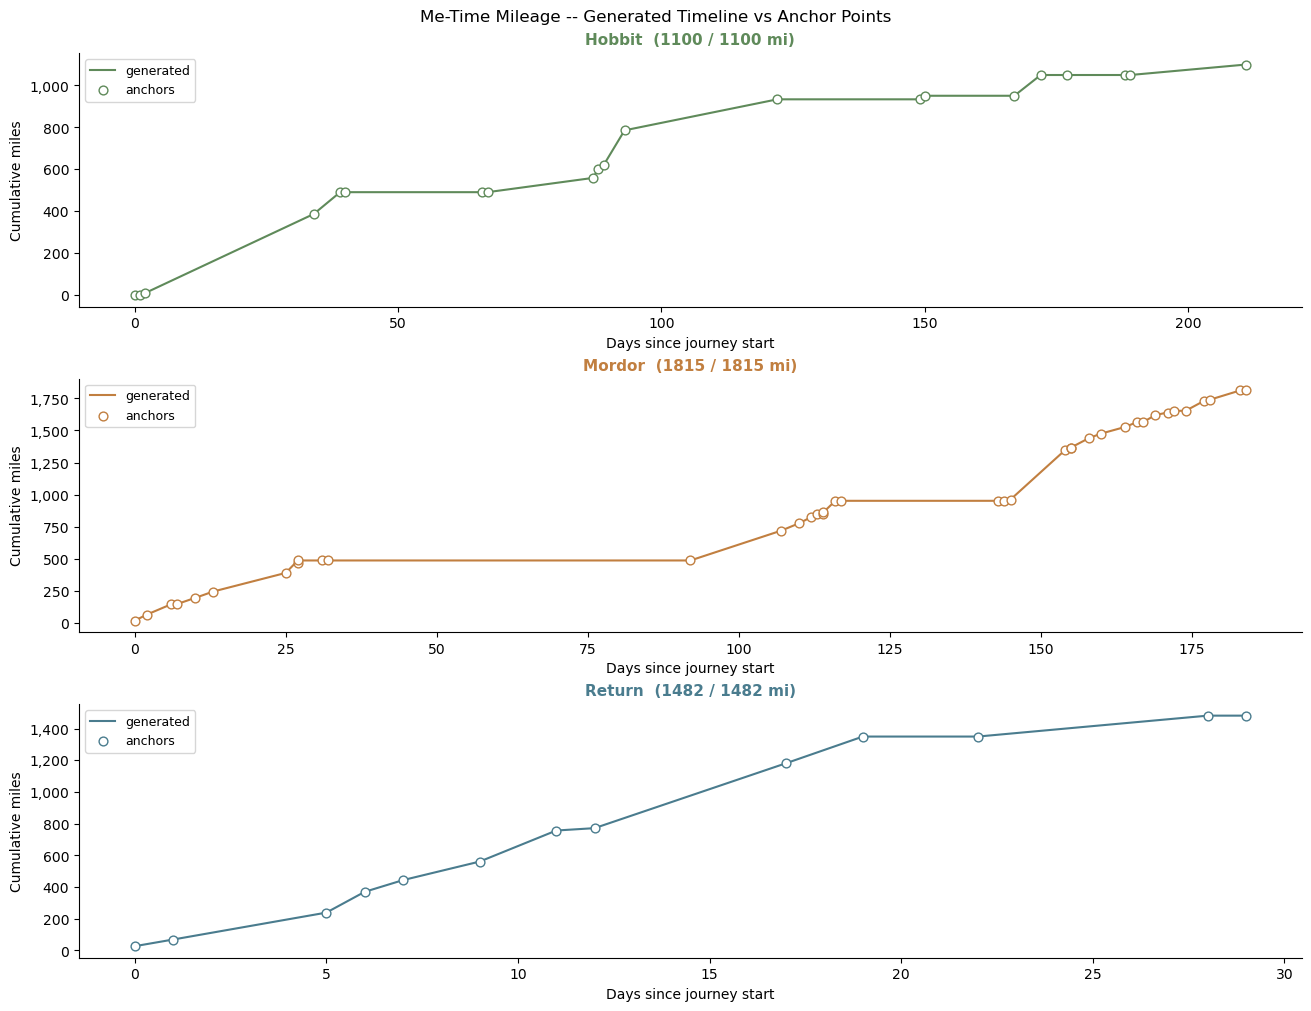

In [10]:
COLORS = {"Hobbit": "#5F8A5A", "Mordor": "#C17F40", "Return": "#4A7C8E"}
fig, axes = plt.subplots(3, 1, figsize=(13, 10), constrained_layout=True)

for ax, jid in zip(axes, ["Hobbit", "Mordor", "Return"]):
    color = COLORS[jid]
    grp   = me_time[me_time["journey_id"] == jid].reset_index(drop=True)
    ax.plot(range(len(grp)), grp["cumulative_miles"],
            color=color, lw=1.5, label="generated")

    janc = anchors[anchors["journey_id"] == jid].dropna(subset=["abs_ord"])
    try:
        first_ord = float(janc["abs_ord"].min())
    except Exception:
        first_ord = 0.0
    x_anc = janc["abs_ord"].astype(float) - first_ord
    ax.scatter(x_anc, janc["mile"],
               color="white", edgecolors=color, s=40, zorder=5, label="anchors")

    ax.set_title(
        f"{jid}  ({grp.iloc[-1]['cumulative_miles']:.0f} / {JOURNEY_TOTALS[jid]} mi)",
        color=color, fontsize=11, fontweight="bold",
    )
    ax.set_ylabel("Cumulative miles")
    ax.set_xlabel("Days since journey start")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Me-Time Mileage -- Generated Timeline vs Anchor Points", fontsize=12)
plt.show()

## Write `me_time.csv`

In [11]:
assert set(me_time.columns) >= {"me_year", "me_date", "me_ordinal", "journey_id", "cumulative_miles"}
assert pd.api.types.is_string_dtype(me_time["me_date"]),    "me_date must be string"
assert me_time["cumulative_miles"].notna().all(),            "no null mileage"
assert me_time["me_date"].notna().all(),                     "no null me_date"
assert me_time["me_ordinal"].notna().all(),                  "no null me_ordinal"

# Ordinals must be non-decreasing within each journey
for jid, grp in me_time.groupby("journey_id"):
    ords = grp["me_ordinal"].values
    assert (ords[1:] >= ords[:-1]).all(), f"{jid}: me_ordinal is not non-decreasing"

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
me_time[["me_year", "me_date", "me_ordinal", "journey_id", "cumulative_miles"]].to_csv(
    OUTPUT_PATH, index=False, float_format="%.1f", lineterminator="\n"
)
print(f"Written: {OUTPUT_PATH}")
print(f"Total rows: {len(me_time):,}\n")

saved = pd.read_csv(OUTPUT_PATH)
for jid in JOURNEY_TOTALS:
    j = saved[saved["journey_id"] == jid]
    print(f"  {jid:8s}  {len(j):4d} rows  "
          f"first={j.iloc[0]['me_date']}@{j.iloc[0]['cumulative_miles']} mi  "
          f"last={j.iloc[-1]['me_date']}@{j.iloc[-1]['cumulative_miles']} mi  "
          f"ordinals {int(j.iloc[0]['me_ordinal'])}..{int(j.iloc[-1]['me_ordinal'])}")

print("\nFiles NOT touched: walking.csv, routes.json, chronology.json, all JS/CSS/HTML.")


Written: c:\Users\johbr\Data-Analyst\Projects\Walk-to-Mordor\docs\static\data\me_time.csv
Total rows: 427

  Hobbit     212 rows  first=2941-04-25@0.0 mi  last=2941-11-23@1100.0 mi  ordinals 115..326
  Mordor     185 rows  first=3018-09-23@18.0 mi  last=3019-03-25@1815.0 mi  ordinals 28390..28574
  Return      30 rows  first=3019-02-26@27.0 mi  last=3019-03-25@1482.0 mi  ordinals 28545..28574

Files NOT touched: walking.csv, routes.json, chronology.json, all JS/CSS/HTML.


In [12]:
# ── Ordinal sequence validation ──────────────────────────────────────────────
saved = pd.read_csv(OUTPUT_PATH)

def _rows(dates, jid=None):
    mask = saved["me_date"].isin(dates)
    if jid:
        mask &= saved["journey_id"] == jid
    return saved[mask][["journey_id","me_date","me_ordinal","cumulative_miles"]].drop_duplicates("me_date").sort_values("me_ordinal")

print("── February 28/29/30 → March 1 (Mordor, T.A. 3019) ──")
df_ = _rows(["3019-02-28","3019-02-29","3019-02-30","3019-03-01"], "Mordor")
print(df_.to_string(index=False))
ords_ = df_["me_ordinal"].tolist()
assert ords_ == list(range(int(ords_[0]), int(ords_[0]) + 4)), "Feb 28/29/30/Mar 1 must be consecutive"
print("  → consecutive ordinals: OK\n")

print("── Intercalary sequence (Hobbit, T.A. 2941) ──")
df_ = _rows(["2941-06-30","1 Lithe","Midyear's Day","2 Lithe","2941-07-01"], "Hobbit")
print(df_.to_string(index=False))
ords_ = df_["me_ordinal"].tolist()
assert ords_ == list(range(int(ords_[0]), int(ords_[0]) + 5)), "Lithe sequence must be consecutive"
print("  → consecutive ordinals: OK\n")

print("── Yule transition (Mordor, T.A. 3018 → 3019) ──")
df_ = _rows(["3018-12-29","3018-12-30","Yule 1","Yule 2","3019-01-01"], "Mordor")
print(df_.to_string(index=False))
ords_ = df_["me_ordinal"].tolist()
assert ords_ == list(range(int(ords_[0]), int(ords_[0]) + 5)), "Yule transition must be consecutive"
print("  → consecutive ordinals: OK\n")

print("── Overlithe unit test (calendar arithmetic, not in data) ──")
# 2944 is the nearest leap year (2944 % 4 == 0)
ol = parse_me_date("Overlithe", year_hint=2944)
l2 = parse_me_date("2 Lithe",   year_hint=2944)
m7 = parse_me_date("2944-07-01")
assert l2["abs_ord"] == ol["abs_ord"] + 1, "2 Lithe must follow Overlithe in leap year"
assert m7["abs_ord"] == l2["abs_ord"] + 1, "July 1 must follow 2 Lithe in leap year"
print(f"  Overlithe ord={ol['abs_ord']}, 2 Lithe ord={l2['abs_ord']}, Jul 1 ord={m7['abs_ord']}: OK\n")

print("── Parallel journeys at 3019-02-26 ──")
df_ = saved[saved["me_date"] == "3019-02-26"][["journey_id","me_ordinal","cumulative_miles"]]
print(df_.to_string(index=False))
assert df_["me_ordinal"].nunique() == 1, "Mordor and Return must share the same ordinal on 3019-02-26"
assert set(df_["journey_id"]) == {"Mordor","Return"}, "Both Mordor and Return must have a row on 3019-02-26"
assert df_[df_["journey_id"]=="Mordor"]["cumulative_miles"].iloc[0] != \
       df_[df_["journey_id"]=="Return"]["cumulative_miles"].iloc[0], "Miles must differ"
print("  → same ordinal, independent miles: OK\n")

print("── Gap: ordinal distance between Hobbit end and Mordor start ──")
h_end  = saved[saved["journey_id"] == "Hobbit"]["me_ordinal"].max()
m_start = saved[saved["journey_id"] == "Mordor"]["me_ordinal"].min()
h_date  = saved[(saved["journey_id"]=="Hobbit")  & (saved["me_ordinal"]==h_end)]["me_date"].iloc[0]
m_date  = saved[(saved["journey_id"]=="Mordor") & (saved["me_ordinal"]==m_start)]["me_date"].iloc[0]
gap     = int(m_start - h_end)
print(f"  Hobbit ends  : ordinal {int(h_end)} ({h_date})")
print(f"  Mordor starts: ordinal {int(m_start)} ({m_date})")
print(f"  Gap          : {gap} ordinals ≈ {gap/365:.1f} years")
assert m_start > h_end, "Mordor must start after Hobbit"
print("  → canonical ordinals correctly span the 77-year period: OK\n")

print("All ordinal validations passed.")


── February 28/29/30 → March 1 (Mordor, T.A. 3019) ──
journey_id    me_date  me_ordinal  cumulative_miles
    Mordor 3019-02-28       28547            1416.3
    Mordor 3019-02-29       28548            1441.0
    Mordor 3019-02-30       28549            1458.5
    Mordor 3019-03-01       28550            1476.0
  → consecutive ordinals: OK

── Intercalary sequence (Hobbit, T.A. 2941) ──
journey_id       me_date  me_ordinal  cumulative_miles
    Hobbit    2941-06-30         180             491.0
    Hobbit       1 Lithe         181             491.0
    Hobbit Midyear's Day         182             491.0
    Hobbit       2 Lithe         183             494.4
    Hobbit    2941-07-01         184             497.8
  → consecutive ordinals: OK

── Yule transition (Mordor, T.A. 3018 → 3019) ──
journey_id    me_date  me_ordinal  cumulative_miles
    Mordor 3018-12-29       28486             548.9
    Mordor 3018-12-30       28487             564.3
    Mordor     Yule 1       28488           